# AI and Applications- Final Assignment
# Name - Pavithra Gopinath
# Matriculation Number - GH1056800
# Sales Performance and Customer Behavior Analysis for Maven Roasters

# 1. Business context
## client company
Maven Roasters is a fictitious coffee shop operating out of three NYC locations. The firm sells various beverages, baked products, and other items in relation to coffee. This data set contains transaction data, which include transaction dates, times, location of stores, products sold, quantity sold, and price per unit sold.
## Business Problem
Even with the availability of huge data on sales, it is important to get insights from such data that will help the management in making appropriate decisions concerning inventory, staffing, and marketing of the firm’s products and services.
## Role of the Data Scientist
Being a data scientist consultant, the objective for this particular study is to carry out an exploratory data analysis (EDA) on the sales dataset of the coffee shops. The EDA would assist us in determining the factors that drive sales and revenues as well as sales and purchasing trends by customers.

# 2. Data Exploration
## Dataset Overview
The dataset consists of 149,116 transaction data rows with 11 variables representing transactions at a coffee shop between January and June 2023. These include transaction numbers, transaction dates and times, store IDs, product category types, product information, units sold, and unit prices.

Dataset Source - https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales
## Data Quality Assessment
Initial analysis revealed that there were no missing values for any columns in the data set. To check for accuracy of the data, duplicate rows were examined. The numeric variables such as the number of transactions and unit price seemed valid.
## Interesting characteristics
This dataset includes extensive transaction-level details about three different stores, thereby allowing us to compare across stores and customer behavior. Moreover, having both date and time details included makes it possible for us to analyze sales on an hourly, daily, and monthly basis. Having more than one product category and type of products included means we can find out which products are responsible for better sales.

As such, the dataset is well-formatted with adequate data for business analysis purposes.

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('Coffee Shop Sales.csv')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
# dataset information
df.info()
# missing values
df.isnull().sum()
# Duplicate records
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


np.int64(0)

# 3. Data Preprocessing
## Data cleaning
Before conducting any analysis on the dataset, there were checks to see whether the data had any missing values, duplicate entries, and wrong data type. There were no missing values detected, suggesting that the dataset is complete.
## Feature Engineering
As part of the business analysis process, a new variable was introduced as the result of multiplying the quantity of a transaction by the price per unit. This variable can serve as an indication of how well a particular transaction went.

The third step in our business analysis process is converting the transaction date and time variables into proper datetime format. We have also added additional features like month, day, and hour to perform analysis at a more granular level.

All the above steps improve the utility of our data set to answer business questions below.

In [4]:
# createing revenew variable
df['revenue'] = df['transaction_qty'] * df['unit_price']

# convering Date column into datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# extracting date feature
df['month'] = df['transaction_date'].dt.month_name()

df['day_of_week'] = df['transaction_date'].dt.day_name()

df['month_num'] = df['transaction_date'].dt.month

# convering time column and exact hour
df['hour'] = pd.to_datetime(
    df['transaction_time'],
    format='%H:%M:%S'
).dt.hour

# checking the corrections
df[['transaction_date',
    'month',
    'day_of_week',
    'hour',
    'revenue']].head()

,transaction_date,month,day_of_week,hour,revenue
0,2023-01-01,January,Sunday,7,6.0
1,2023-01-01,January,Sunday,7,6.2
2,2023-01-01,January,Sunday,7,9.0
3,2023-01-01,January,Sunday,7,2.0
4,2023-01-01,January,Sunday,7,6.2


# 4. Explanatory Data Analysis
## Business Question 1
## 1.Which Store Location Generates the Highest Revenue and Sales Volume?
## Business Importance:
The performance of the store is one of the important factors that determine the success of a business. The determination of the best performing store allows the managers to know from which store revenues are being made, and thus make plans for duplication of the same practices in other outlets.
## Analysis
In answering this question, the data will be analyzed based on the store's geographical locations. The total revenue, total units sold, and total number of transactions for each individual store will be determined.


In [5]:
store_performance = (
    df.groupby('store_location')
      .agg(
          total_revenue=('revenue', 'sum'),
          total_quantity=('transaction_qty', 'sum'),
          total_transactions=('transaction_id', 'count')
      )
      .sort_values('total_revenue', ascending=False)
)

store_performance

,total_revenue,total_quantity,total_transactions
store_location,,,
Hell's Kitchen,236511.17,71737,50735
Astoria,232243.91,70991,50599
Lower Manhattan,230057.25,71742,47782


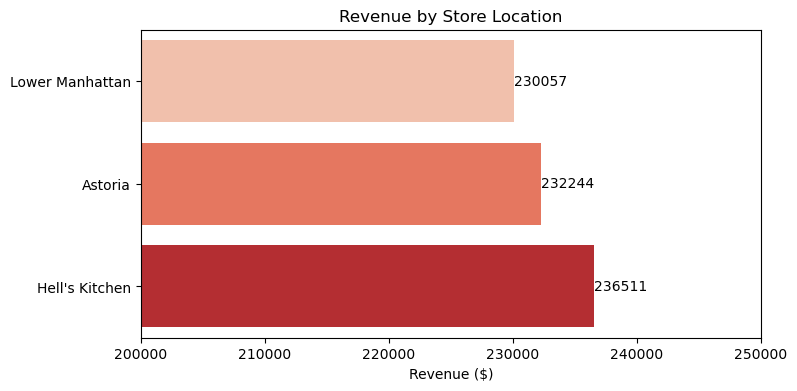

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = store_performance.reset_index().sort_values(
    'total_revenue'
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=plot_data,
    x='total_revenue',
    y='store_location',
    hue='store_location',
    palette='Reds',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.xlim(200000, 250000)  
plt.title('Revenue by Store Location')
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.show()

## Results and interpretations:
The program categorizes the figures according to location of the stores and calculates revenues, number of units sold, and transactions. According to the findings, Hell's Kitchen has been the top performer in terms of revenues of 236,511, followed by Astoria and Lower Manhattan with revenues of 232,244 and $230,057, respectively. While the differences are not very wide, Hell's Kitchen has been the top performer in revenues.
## Business Recommendation:
Management needs to figure out what leads to these high revenues from Hell's Kitchen and replicate this success elsewhere.

# 2. What Are the Busiest Hours of the Day?
## Business Importance
Understanding when the maximum number of transactions takes place will enable the company to manage their employees, prepare inventory and design promotion plans. Learning when clients need their services mostly will improve the performance and provide for better-quality service.

In [7]:
hourly_sales = (
    df.groupby('hour')
      .agg(
          revenue=('revenue', 'sum'),
          transactions=('transaction_id', 'count')
      )
      .reset_index()
)

hourly_sales

,hour,revenue,transactions
0,6,21900.27,4594
1,7,63526.47,13428
2,8,82699.87,17654
3,9,85169.53,17764
4,10,88673.39,18545
5,11,46319.14,9766
6,12,40192.79,8708
7,13,40367.45,8714
8,14,41304.74,8933
9,15,41733.10,8979


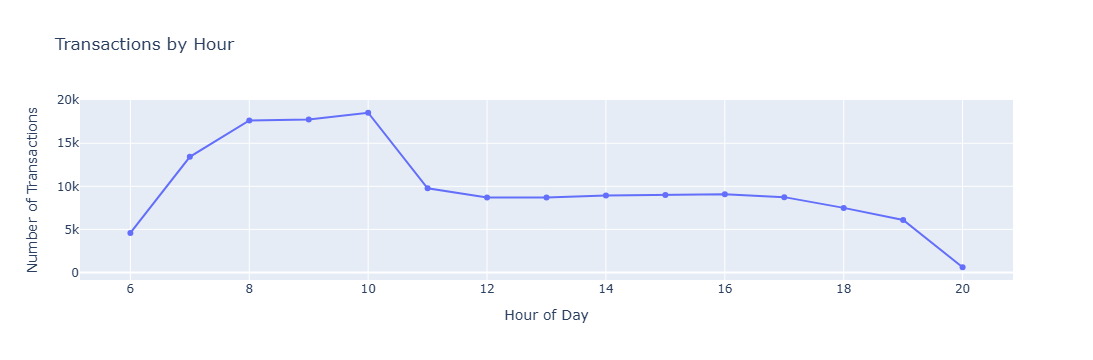

In [8]:
import plotly.express as px

fig = px.line(
    hourly_sales,
    x='hour',
    y='transactions',
    markers=True,
    title='Transactions by Hour'
)

fig.update_layout(
    xaxis_title='Hour of Day',
    yaxis_title='Number of Transactions'
)

fig.show()

## Results and Interpretations
This Code shows table which categorizes transactions into different hours. The total number of transactions during peak hour was 18,545 earning an income of $88,673 during the peak hour. The peak hour is between 8 am to 11 am whereas the transaction drops after noon. 
## Business Recommendation
1. Schedule more staff during 8 AM–11 AM.
2. Ensure sufficient stock is available before the morning rush.
3. Introduce promotions during slower afternoon and evening hours to increase sales.

# 3. Which Product Categories Generate the Most Revenue?
## Business Importance
Analyzing which product categories make more sales gives insight to the management as to what drives the business performance, and thus can help in developing sales strategy, planning inventory, and promotion.



In [9]:
category_sales = (
    df.groupby('product_category')
      .agg(
          revenue=('revenue', 'sum'),
          quantity_sold=('transaction_qty', 'sum')
      )
      .sort_values('revenue', ascending=False)
      .reset_index()
)

category_sales

,product_category,revenue,quantity_sold
0,Coffee,269952.45,89250
1,Tea,196405.95,69737
2,Bakery,82315.64,23214
3,Drinking Chocolate,72416.00,17457
4,Coffee beans,40085.25,1828
5,Branded,13607.00,776
6,Loose Tea,11213.60,1210
7,Flavours,8408.80,10511
8,Packaged Chocolate,4407.64,487


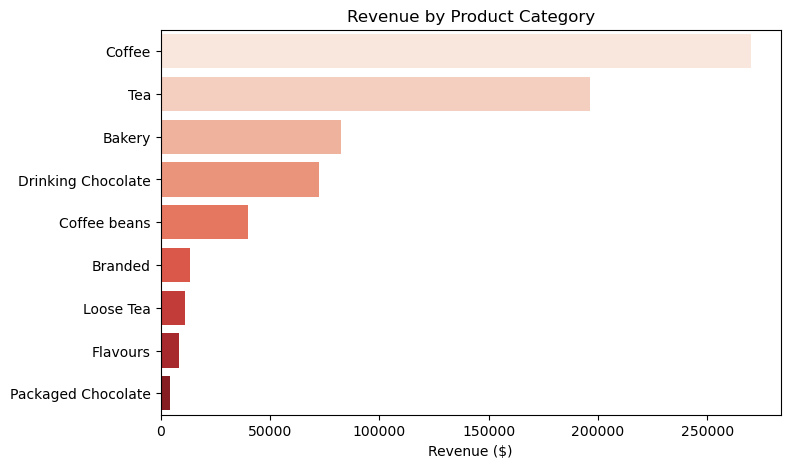

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x='revenue',
    y='product_category',
    hue='product_category',
    palette='Reds',
    legend=False
)

plt.title('Revenue by Product Category')
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.show()

## Results and Interpretation
The report shows that the top category in terms of sales performance is Coffee, making 269,952 sales and selling 89,250 items. The second-highest category in terms of sales is Tea, followed by Bakery with 196,406 and 82,316 respectively.
From this, we learn that beverages, especially Coffee and Tea, drive sales and form the major portion of sales in the company.
## Business Recommendation
1. Prioritise inventory and marketing efforts for Coffee and Tea products.
2. Create bundle offers combining beverages with Bakery items to increase sales.
3. Review low-performing categories and consider promotional strategies to improve their contribution to revenue.

# 4. Which Day of the Week Is the Busiest?
## Business Importance
Knowing on which days there is a lot of customer traffic makes it easier for the management to organize staff scheduling, stocking, and other store activities. It is useful to know the days that are busiest and the days that are quietest to better organize the use of company assets and minimize waiting times in busy days.

In [11]:
weekday_sales = (
    df.groupby('day_of_week')
      .agg(
          transactions=('transaction_id', 'count')
      )
      .reset_index()
)

order = ['Monday', 'Tuesday', 'Wednesday',
         'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_sales['day_of_week'] = pd.Categorical(
    weekday_sales['day_of_week'],
    categories=order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values('day_of_week')

weekday_sales

,day_of_week,transactions
1,Monday,21643
5,Tuesday,21202
6,Wednesday,21310
4,Thursday,21654
0,Friday,21701
2,Saturday,20510
3,Sunday,21096


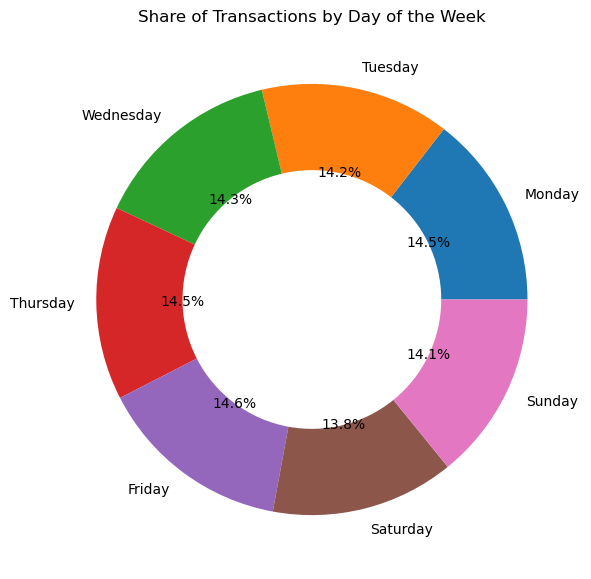

In [12]:
plt.figure(figsize=(7,7))

plt.pie(
    weekday_sales['transactions'],
    labels=weekday_sales['day_of_week'],
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4}
)

plt.title('Share of Transactions by Day of the Week')
plt.show()

## Results and Interpretations
This program classifies transactions into days of the week and determines the number of transactions for each of these days. According to the findings, the day with the highest transaction volume is Friday (21,701), while the day with the least volume of transactions is Saturday (20,510). 

On average, customers exhibit similar transaction behavior throughout the week, although there is increased activity during weekdays.
##  Business Recommendations:
1. Addition of staff and stock should be done on Fridays due to increased demand for services on that day.
2. Promotions can be organized on Saturdays as it is the busiest day for customers.
3. Planning should remain consistent as transaction levels do not vary much during the week.

# 5. How Does Customer Demand Differ Between Weekdays and Weekends?
## Business Importance
Being aware of the difference between weekday and weekend demands will help the management make proper decisions regarding staffing, inventory control, and marketing campaigns. In case customer behavior is quite different from weekdays to weekends, then this knowledge will assist in making changes in order to satisfy the demand.

In [18]:
df['day_type'] = np.where(
    df['day_of_week'].isin(['Saturday', 'Sunday']),
    'Weekend',
    'Weekday'
)
daily_revenue = (
    df.groupby(['transaction_date', 'day_type'])
      .agg(revenue=('revenue', 'sum'))
      .reset_index()
)
daily_revenue.groupby('day_type')['revenue'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
day_type,,,,,,,,
Weekday,130.0,3873.75,1189.14,2203.4,2848.20,3537.98,4846.42,6403.91
Weekend,51.0,3827.94,1195.63,2037.1,2879.74,3408.36,4779.10,6117.60


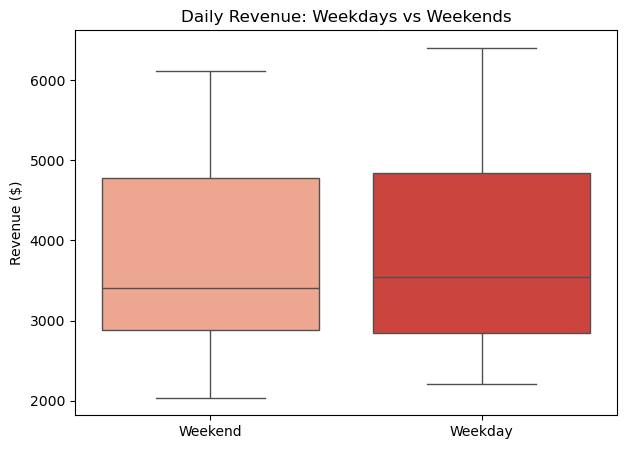

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=daily_revenue,
    x='day_type',
    y='revenue',
    hue='day_type',
    palette='Reds',
    legend=False
)

plt.title('Daily Revenue: Weekdays vs Weekends')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.show()

## Results and Interpretations:
The analysis involves comparison of daily revenues during weekdays versus weekends. Daily revenues during weekdays ($3,874) are slightly higher compared to daily revenues during weekends (3,828). Median daily revenues are also comparable, thus revealing that customer expenditures are fairly constant across the week.

In summary, the analysis reveals that demand is stable, as there is no significant difference in sales performances during weekdays and weekends.
## Business Importance:
1. Similar staffing and inventory must be maintained throughout the week.
2. Promotion strategies should be tailored towards certain days, which perform poorly, rather than focusing on all weekends.
3. Customer demand trends need to be watched to notice any shift in consumer behavior in the future.

# 6. Which Products Generate the Highest Revenue?
The ability to distinguish between the items that bring in the largest amount of income for the business enables management to know how their customers spend money and identify the best-performing items. Management will then be able to take actions concerning their inventory, pricing, positioning of products, as well as marketing activities, based on the information gathered from the analysis of the items that sell the best.

In [26]:
product_sales = (
    df.groupby('product_detail')
      .agg(
          revenue=('revenue', 'sum'),
          quantity_sold=('transaction_qty', 'sum')
      )
      .sort_values('revenue', ascending=False)
      .head(10)
      .reset_index()
)

product_sales

,product_detail,revenue,quantity_sold
0,Sustainably Grown Organic Lg,21151.75,4453
1,Dark chocolate Lg,21006.00,4668
2,Latte Rg,19112.25,4497
3,Cappuccino Lg,17641.75,4151
4,Morning Sunrise Chai Lg,17384.00,4346
5,Latte,17257.50,4602
6,Jamaican Coffee River Lg,16481.25,4395
7,Sustainably Grown Organic Rg,16233.75,4329
8,Cappuccino,15997.50,4266
9,Brazilian Lg,15109.50,4317


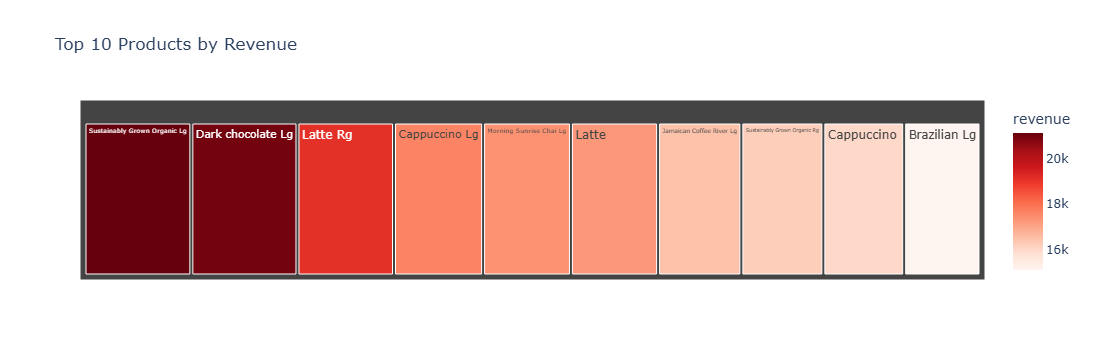

In [27]:
import plotly.express as px

fig = px.treemap(
    product_sales,
    path=['product_detail'],
    values='revenue',
    color='revenue',
    color_continuous_scale='Reds',
    title='Top 10 Products by Revenue'
)

fig.show()

## Results and Interpretations:
Products are ranked according to their total income earned. Sustainably Grown Organic Lg earns the company the highest income at $21,152 while the Dark Chocolate Lg comes second with an income of 21,006. There are other products based on coffee that earn the company considerable amounts of money such as Latte and Cappuccino.

This means that the largest sizes of beverages are popular among the customers.
## Business Importance:
1. Ensure that there is enough stock for your best-selling items, particularly those large drinks.

2. Focus on promoting these items in your marketing efforts and displays.

3. Include packages that include your top-selling beverages to boost earnings.

# 7. Store Performance During Peak Hours
Knowing how the store is performing in its peak times would help in the effective distribution of employees. This would enable the company to know which store has more customers at its peak times and thus be able to implement the same strategies in other stores.

In [28]:
peak_sales = (
    df[df['hour'].between(8, 10)]
    .groupby('store_location')
    .agg(
        revenue=('revenue', 'sum'),
        transactions=('transaction_id', 'count')
    )
    .reset_index()
)

peak_sales

,store_location,revenue,transactions
0,Astoria,70415.59,15340
1,Hell's Kitchen,98024.54,20633
2,Lower Manhattan,88102.66,17990


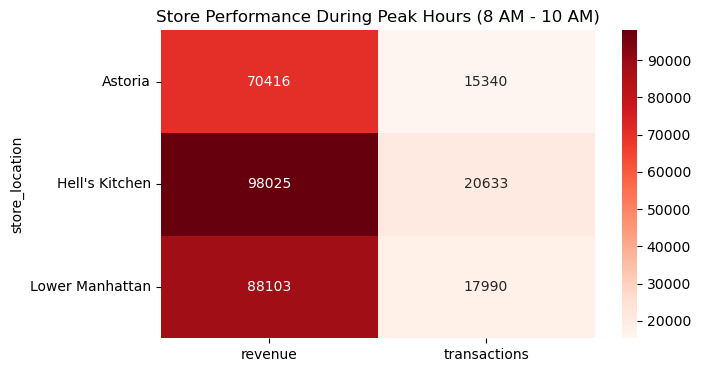

In [29]:
plt.figure(figsize=(7,4))

sns.heatmap(
    peak_sales.set_index('store_location'),
    annot=True,
    fmt='.0f',
    cmap='Reds'
)

plt.title('Store Performance During Peak Hours (8 AM - 10 AM)')
plt.show()

## Results and Interpretations:
Performance of the store in peak hours of 8 AM to 10 AM is being analyzed in this report. It is found through this analysis that Hell's Kitchen has outperformed all the other stores in peak hours by earning total sales of 98,025 through 20,633 customers. The store after Hell's Kitchen which earns the most in sales is Lower Manhattan (88,103/17,990) and Astoria is the poorest performer in terms of sales ($70,416/15,340).

It can be concluded that Hell's Kitchen attracts the highest number of customers in peak hours of the day.
## Business Recommendations:
1.Assign more staff members and stock to Hell’s Kitchen during peak times to ensure high-quality services.

2.Identify the drivers for the successful operations of Hell’s Kitchen and implement the proven methods for other branches.

3.Introduce promotional activities or improvements in operations in Astoria to attract customers during peak times.

# Final Discussion
In this analysis, purchasing behavior of the customers, performance of the store, performance of the products, and sales trends were considered in the coffee shop data set. Revenue distribution is fairly even among all the locations, with Hell’s Kitchen being slightly more efficient overall. Customers’ demand is at its highest point during the early hours of the day, mostly between 8 am to 10 am, emphasizing the importance of having an adequate workforce and sufficient stock of goods during these times.

Coffee & Tea categories generate most of the revenue, and large-sized drinks have proven to be highly profitable.

# Advantages and Disadvantages
The use of transaction-level data is one of the key advantages of this analysis; it enables to see the behavior of the customers and their sales patterns clearly. Nonetheless, the dataset is small in scale and lacks such influencing variables as the weather or customer demographics.

# Recommendations
1. Increase staff and inventory during the busiest mornings
2. Concentrate on high-selling items, particularly larger drinks
3. Implement winning strategies employed at Hell’s Kitchen in other outlets
4. Employ promotions to increase sales during off-peak times
5. Continue tracking trends for improved forecasting

# Conclusion
In general, this analysis gives important insights about the behavior of customers in terms of purchases, the performance of products and the sales tendencies at the store level. There are certain peak periods that have been identified in terms of demand, especially in the morning. Moreover, the products that generate the highest revenues for the company are Coffee and Tea.

Furthermore, it has become apparent that there are no significant differences in terms of performance among different stores but with certain operational improvements it is possible to increase the efficiency even more. For example, it is necessary to learn from the best-performing store. Although there is only a limited dataset available, without any outside factors, the analysis provides good grounds for further decisions and forecasts.